In [ ]:
import random

import numpy as np
import pandas as pd
import seaborn as sns

from matplotlib import pyplot as plt
from utils.config import Config
from data_handler import DataHandler
# from classificators.dummy_classifier import DummyClassifier
# from classificators.random_forest_classifier import RandomForestClassifierSK
# from utils.utils import calculate_mcc_multilabel, plot_per_class_confusion

pd.options.display.float_format = '{:.6f}'.format

In [5]:
config = Config()

# Seeding
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
val_mccs = []
test_mccs = []
lr_histories_by_fold = {}

# load data
datahandler = DataHandler(config=config)

Local dataset found: data\cps_data_multi_label.pkl
Loading data into memory...
Data loaded.


In [ ]:
for fold in range(1, 2):
    val_id = fold + 1 if fold < 4 else 1

    datahandler.config.data.test_experiment_id = fold
    datahandler.config.data.validation_experiment_id = val_id

    train, val, test, target_vals = datahandler.get_data_loaders()
    print("Full Data Shape")
    print(train.shape, val.shape, test.shape)
    print("Target columns:", target_vals)
    print("Train columns:", train.columns.tolist())
    X_train = train.iloc[:, :8]
    y_train = train.iloc[:, 8:]
    X_val = val.iloc[:, :8]
    y_val = val.iloc[:, 8:]
    X_test = test.iloc[:, :8]
    y_test = test.iloc[:, 8:]

Starting data preparation...
Full Data Shape
(2136599, 15) (941667, 15) (1108546, 15)
Target columns: ['Driving(curve)', 'Driving(straight)', 'Lifting(lowering)', 'Lifting(raising)', 'Stationary processes', 'Turntable wrapping']
Train columns: ['time', 'Acc.x', 'Acc.y', 'Acc.z', 'Gyro.x', 'Gyro.y', 'Gyro.z', 'Baro.x', 'No loading', 'Driving(straight)', 'Driving(curve)', 'Lifting(raising)', 'Lifting(lowering)', 'Turntable wrapping', 'Stationary processes']


In [7]:
sensor_cols = ["Acc.x","Acc.y","Acc.z","Gyro.x","Gyro.y","Gyro.z","Baro.x"]
def sliding_window_stats_overlapping(X_df, window_size=10000, step=5000, sensor_cols=None):

    if sensor_cols is None:
        sensor_cols = [c for c in X_df.columns if c != "time"]

    features = {
        "mean": [],
        "std": [],
        "min": [],
        "max": [],
        "median": []
    }

    for start in range(0, len(X_df) - window_size + 1, step):
        end = start + window_size
        window = X_df.iloc[start:end]

        mean_vals = window[sensor_cols].mean().values
        std_vals = window[sensor_cols].std().values
        min_vals = window[sensor_cols].min().values
        max_vals = window[sensor_cols].max().values
        median_vals = window[sensor_cols].median().values

        features["mean"].append(mean_vals)
        features["std"].append(std_vals)
        features["min"].append(min_vals)
        features["max"].append(max_vals)
        features["median"].append(median_vals)

    return features

In [8]:
def sliding_window_stats_non_overlapping(X_df, window_size=10000, sensor_cols=None):
    if sensor_cols is None:
        sensor_cols = [c for c in X_df.columns if c != "time"]

    features = {
        "mean": [],
        "std": [],
        "min": [],
        "max": [],
        "median": []
    }

    for start in range(0, len(X_df) - window_size + 1, window_size):
        end = start + window_size
        window = X_df.iloc[start:end]

        features["mean"].append(window[sensor_cols].mean().values)
        features["std"].append(window[sensor_cols].std().values)
        features["min"].append(window[sensor_cols].min().values)
        features["max"].append(window[sensor_cols].max().values)
        features["median"].append(window[sensor_cols].median().values)

    return features

In [9]:
def plot_all_features_sensor(features, sensor_name, sensor_cols, start=0, end=None):

    sensor_idx = sensor_cols.index(sensor_name)
    feature_names = list(features.keys())
    n_features = len(feature_names)

    fig, axes = plt.subplots(n_features, 1, figsize=(12, 3*n_features), sharex=True)

    for i, feature in enumerate(feature_names):
        data = np.array(features[feature])
        sensor_values = data[start:end, sensor_idx]

        axes[i].plot(range(start, start + len(sensor_values)), sensor_values)
        axes[i].set_title(f"{feature} of {sensor_name}")
        axes[i].set_ylabel(feature)
        axes[i].grid(True)

    axes[-1].set_xlabel("Window index")
    plt.tight_layout()
    plt.show()

In [10]:
overlapping_stats = sliding_window_stats_overlapping(X_train, window_size=10000, step=5000, sensor_cols=sensor_cols)
non_overlapping_stats = sliding_window_stats_non_overlapping(X_train, window_size=10000, sensor_cols=sensor_cols)


Acc.x


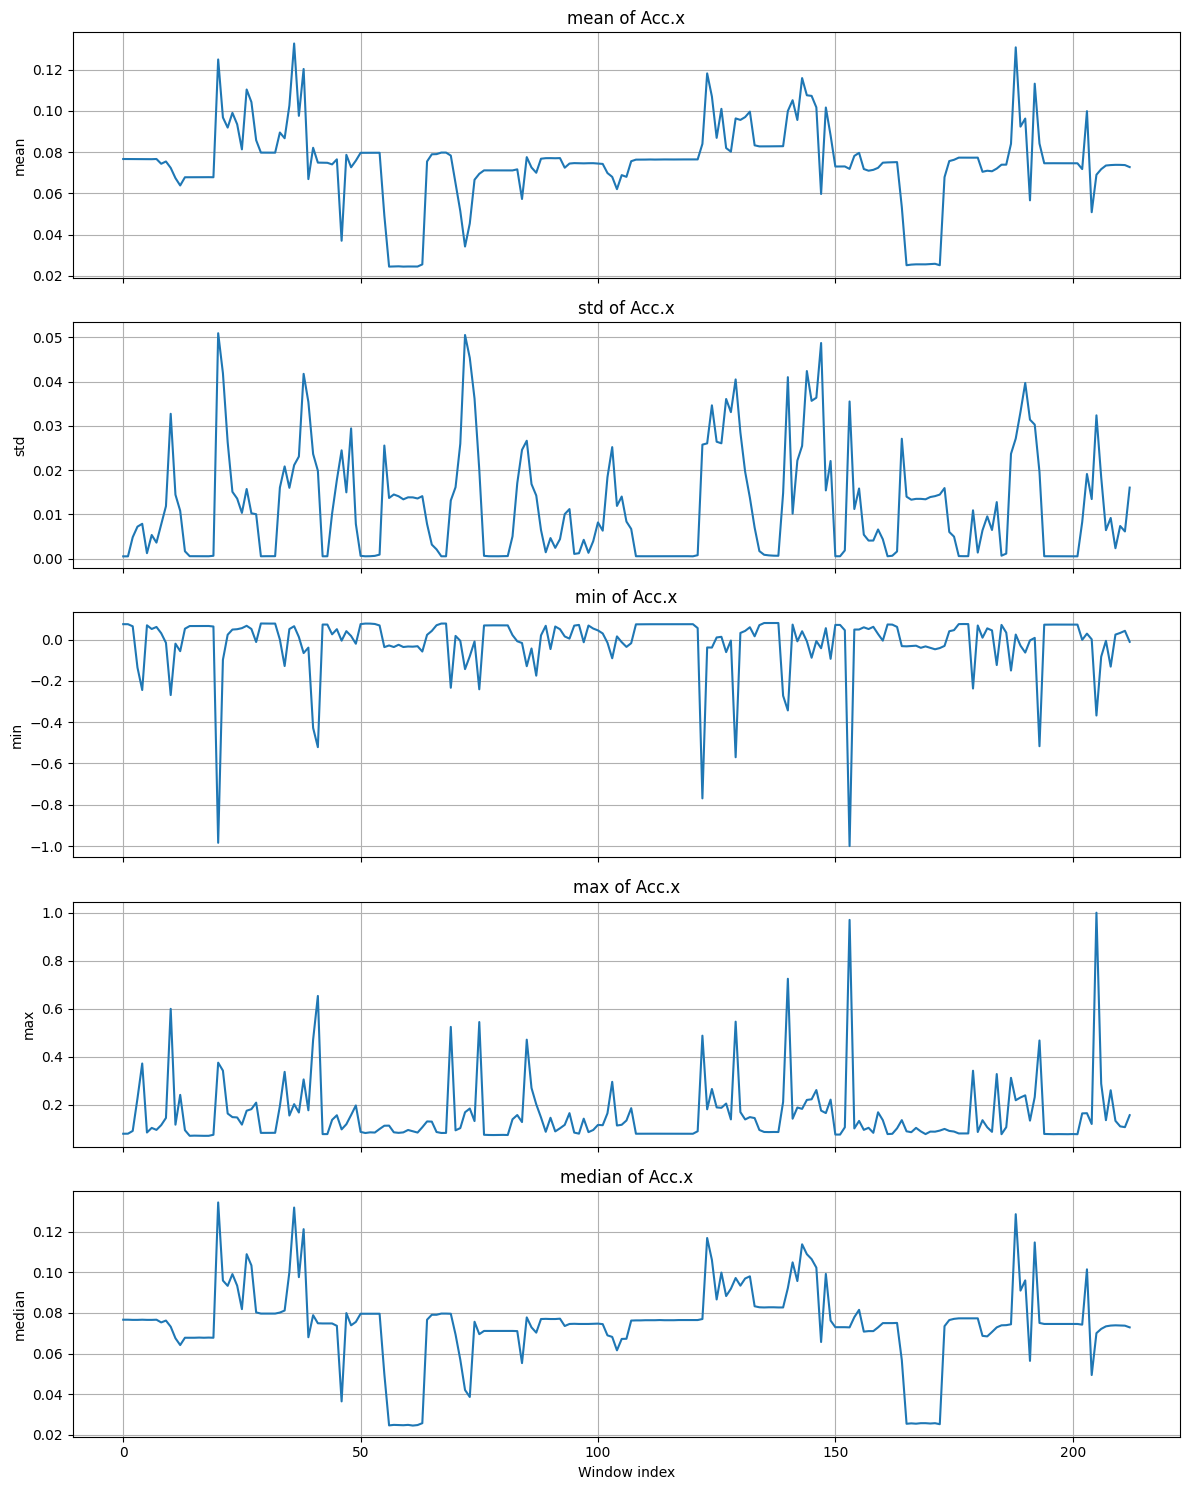


Acc.y


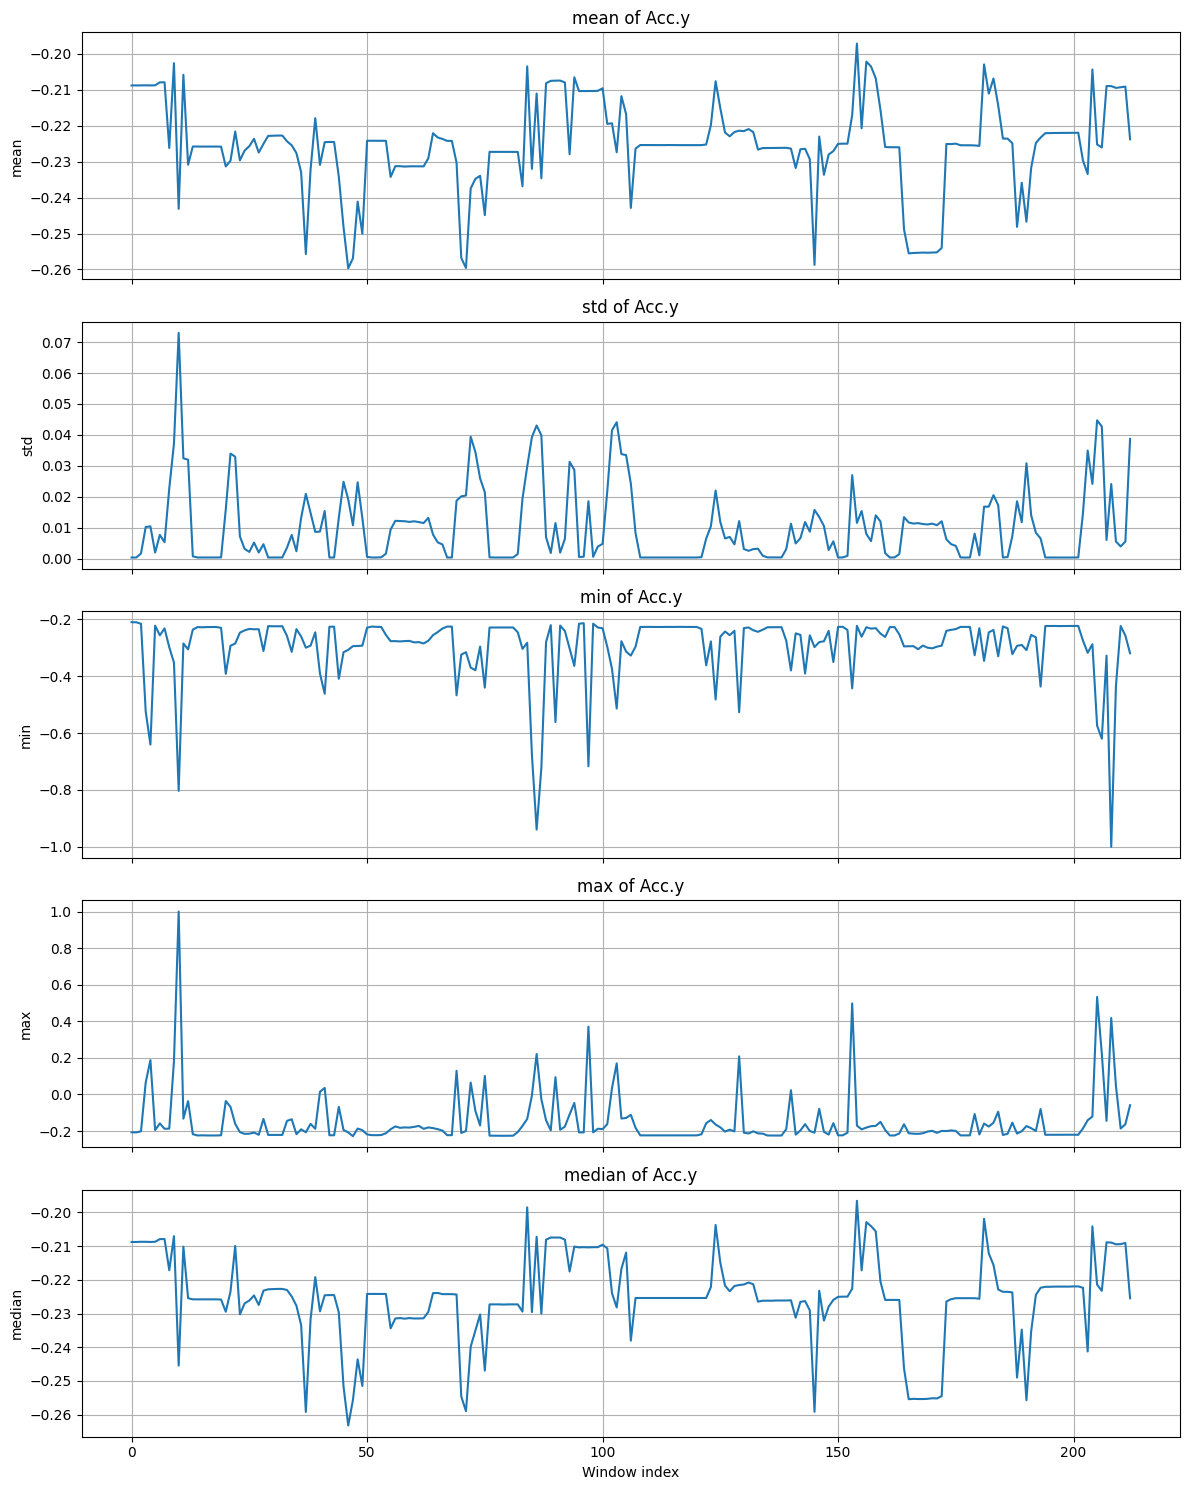


Acc.z


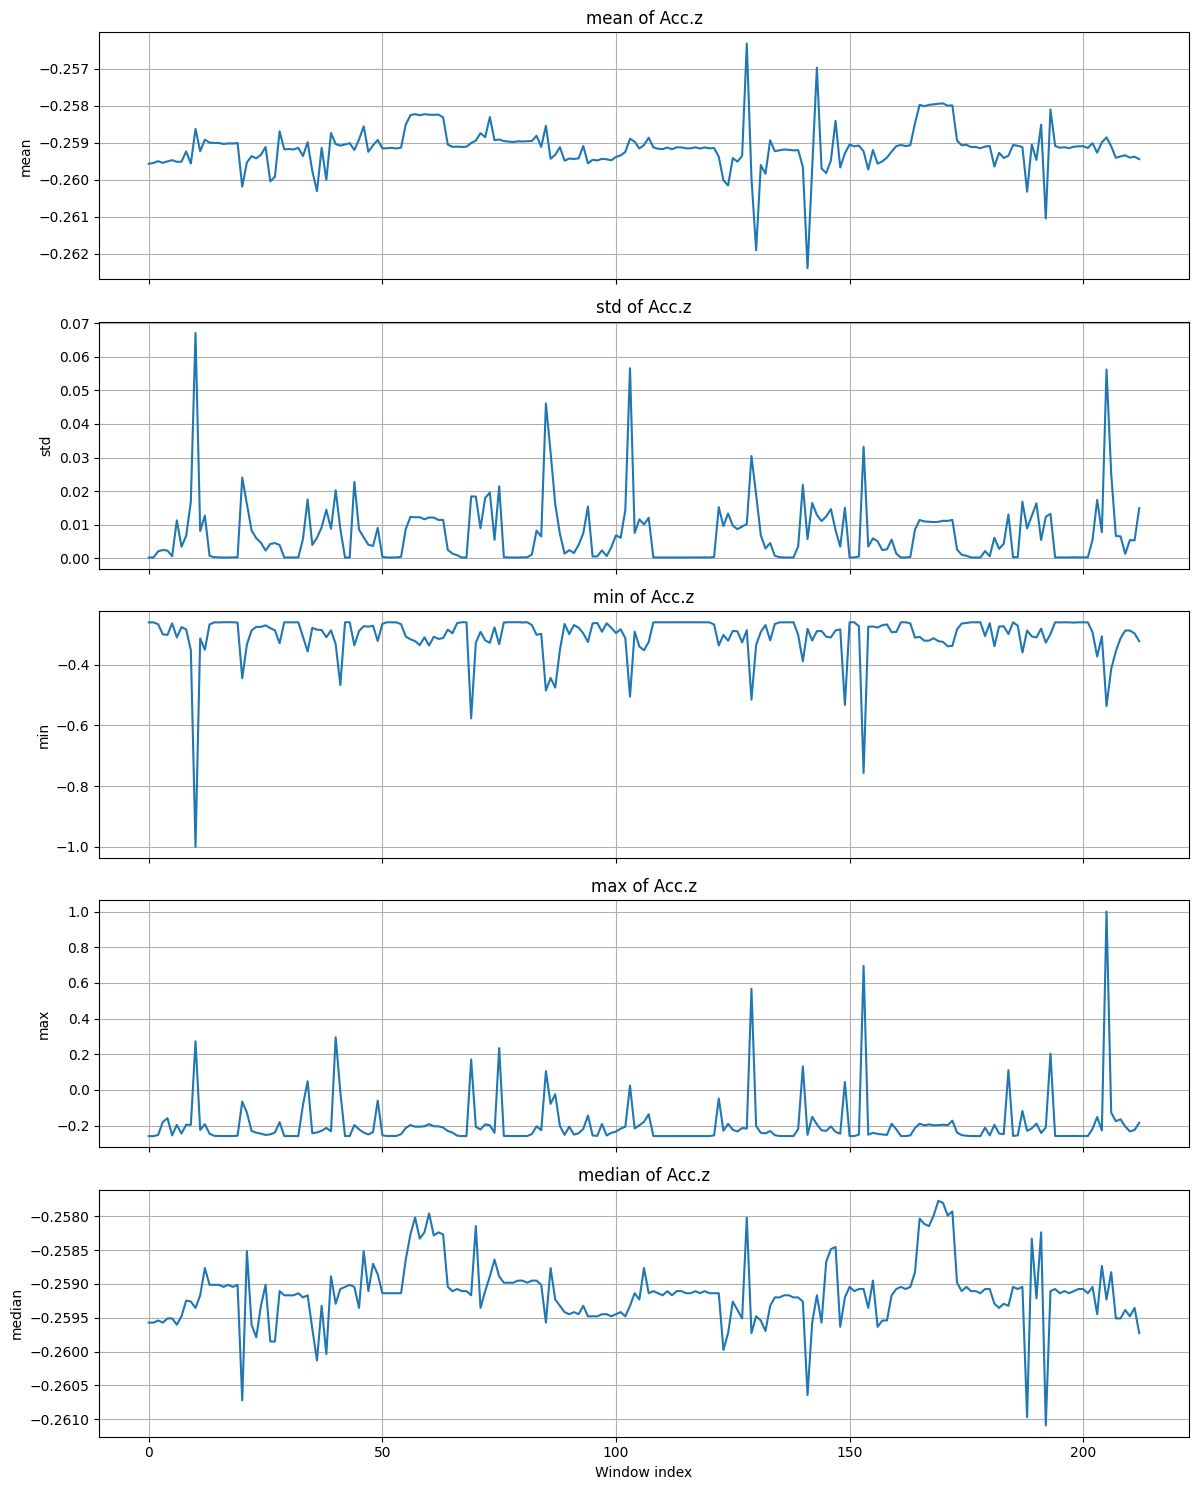


Gyro.x


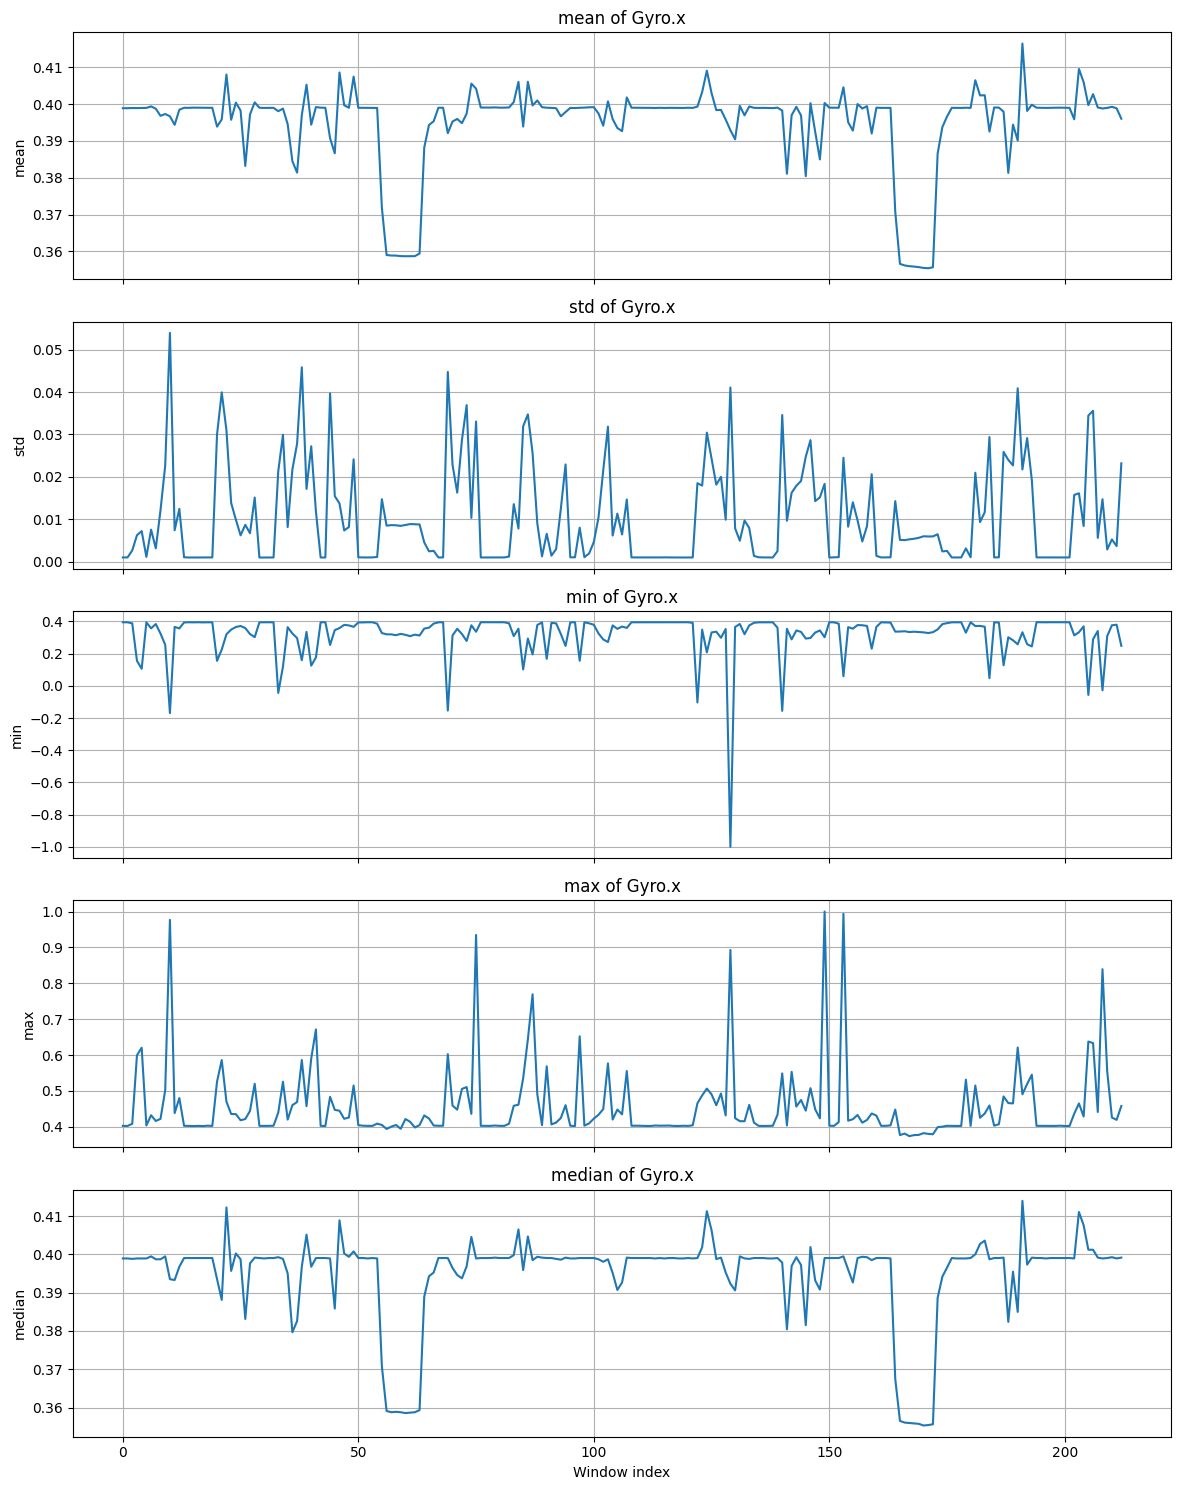


Gyro.y


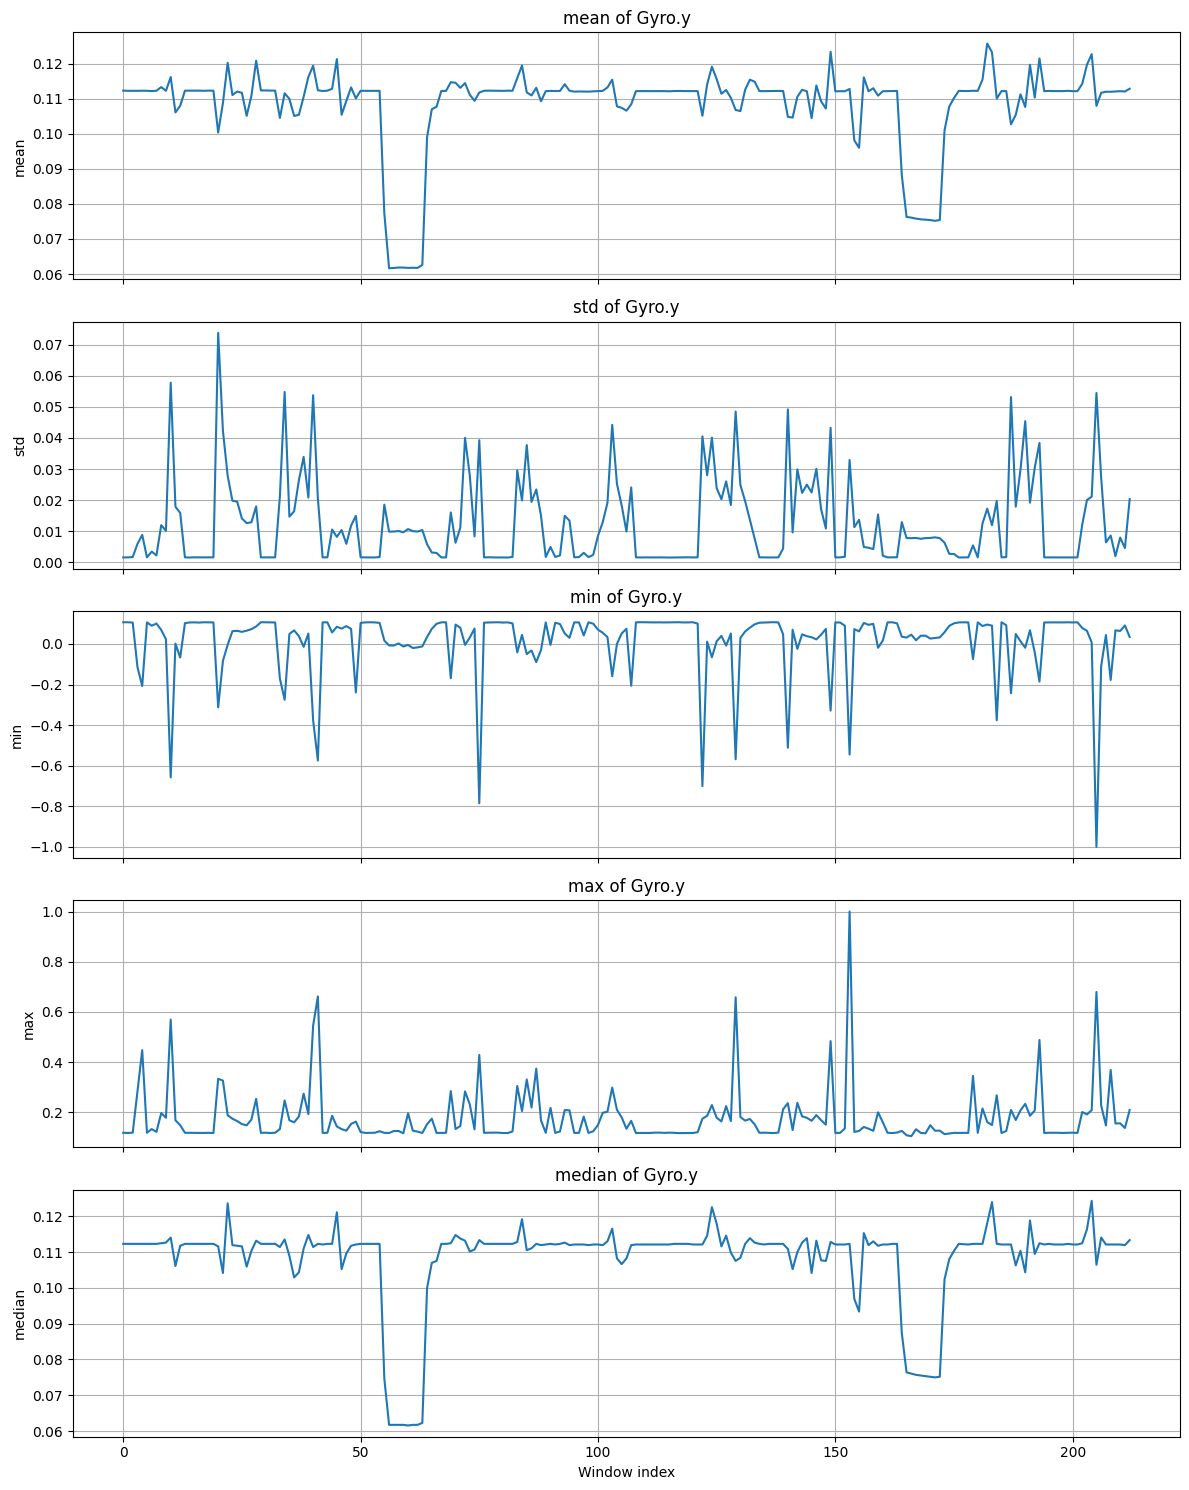


Gyro.z


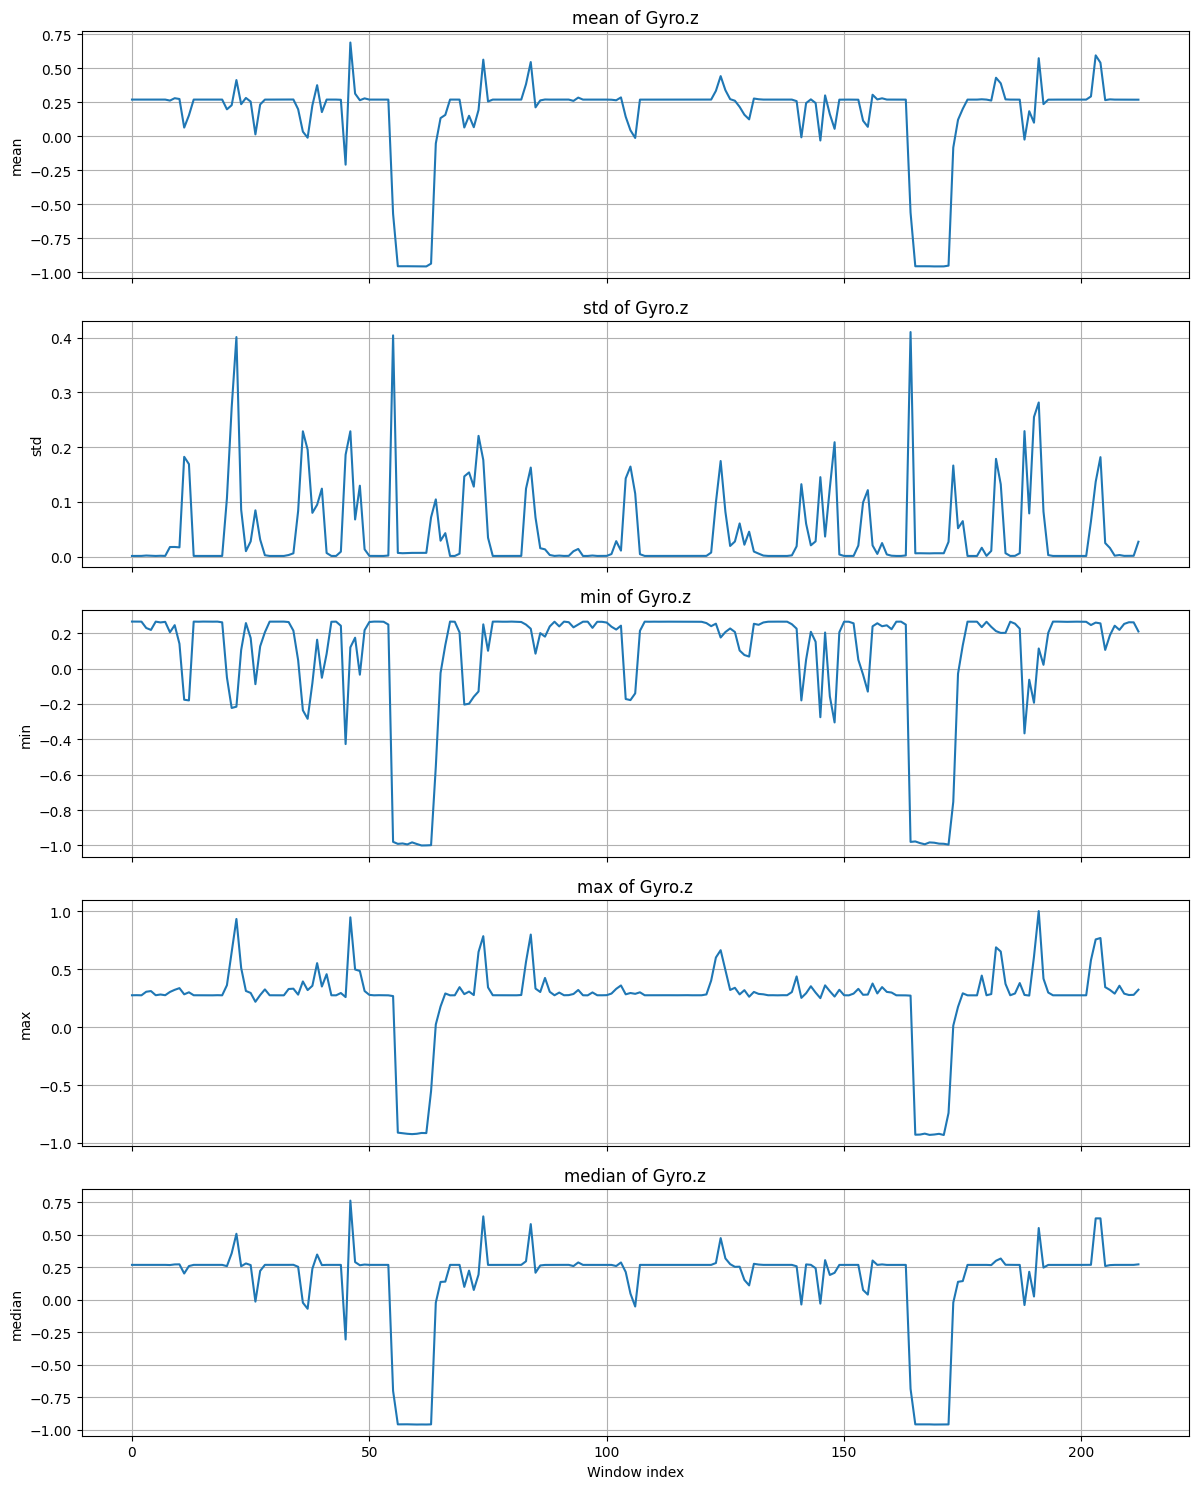


Baro.x


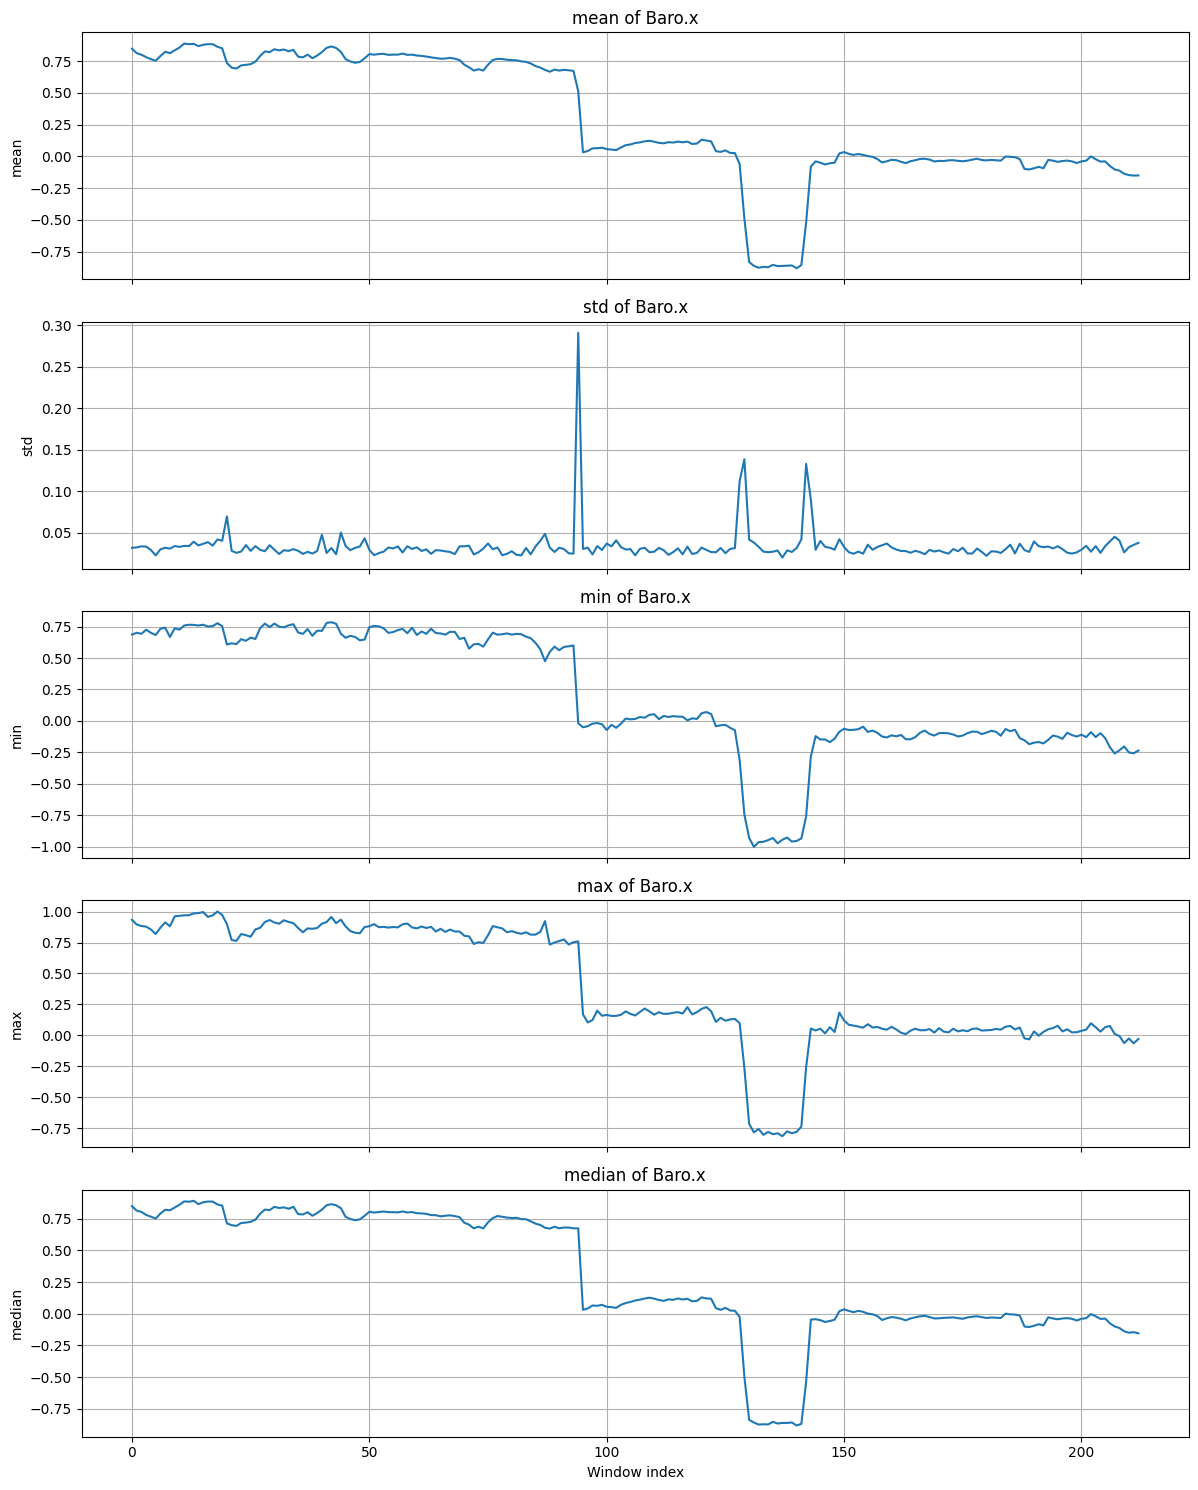

In [11]:
for sensor in sensor_cols:
    print("\n" + sensor)
    plot_all_features_sensor(non_overlapping_stats, sensor, sensor_cols)

In [13]:
def analyze_class_distribution(y_df):

    class_counts = y_df.sum()

    class_percent = (class_counts / len(y_df)) * 100

    print("Class counts:")
    print(class_counts)
    print("\nClass percentage:")
    print(class_percent)

    plt.figure(figsize=(8,4))
    class_counts.sort_values(ascending=False).plot(kind="bar")
    plt.ylabel("Number of samples")
    plt.title("Class distribution")
    plt.grid(axis="y")
    plt.show()

    return class_counts, class_percent

Class counts:
No loading                   0
Driving(straight)       343555
Driving(curve)          374251
Lifting(raising)         63600
Lifting(lowering)        89219
Turntable wrapping      235214
Stationary processes    932888
dtype: int64

Class percentage:
No loading              0.000000
Driving(straight)      16.079526
Driving(curve)         17.516202
Lifting(raising)        2.976693
Lifting(lowering)       4.175748
Turntable wrapping     11.008804
Stationary processes   43.662288
dtype: float64


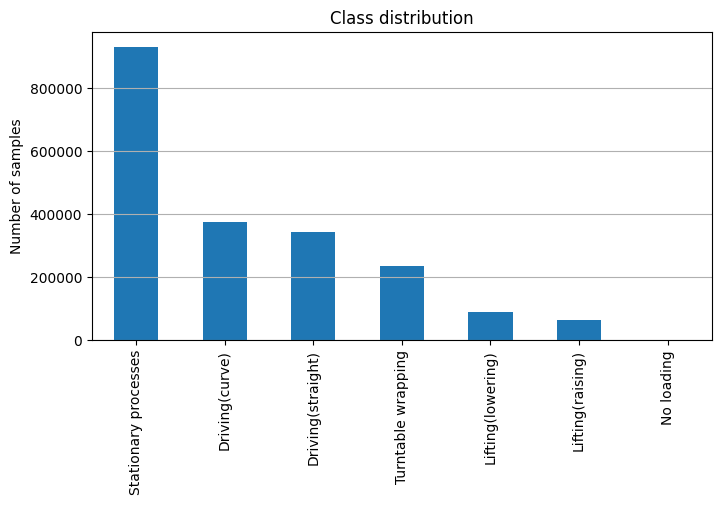

In [14]:
counts, perc = analyze_class_distribution(y_train)

In [17]:
def sensor_density_corr_analysis(df):

    # automatically detect sensors
    sensor_cols = [c for c in df.columns if c != "time"]

    data = df[sensor_cols]

    # Pairwise density / histogram plots
    sns.pairplot(
        data,
        diag_kind="kde",
        corner=True
    )

    plt.suptitle("Sensor Pairwise Density Plots", y=1.02)
    plt.show()

    #Correlation matrix
    corr = data.corr(method="spearman")

    plt.figure(figsize=(8,6))
    sns.heatmap(
        corr,
        annot=True,
        cmap="coolwarm",
        center=0,
        fmt=".2f"
    )

    plt.title("Sensor Spearman Correlation Matrix")
    plt.tight_layout()
    plt.show()

In [ ]:
sensor_density_corr_analysis(X_train)